# Flujos de Trabajo en Ciencia de Datos Financiera

Este cuaderno establece la **plantilla de flujo de trabajo** que usaremos en cada sesión del curso: la secuencia estándar `Carga de datos → Limpieza → Features → Modelo → Evaluación`. No es un tema más, es el **patrón operativo** sobre el que se apoyan todos los demás cuadernos.

El cuaderno está organizado en cuatro bloques:

1. **Setup reproducible**: la plantilla de flujo de trabajo y una convención simple de control de versiones para nombrar y guardar archivos.
2. **Descarga de datos reales**: precios y estados financieros de varias empresas con `yfinance`, comparados con una fuente de datos de crédito para *scoring*.
3. **Pipeline de limpieza**: ejercicio guiado sobre un dataset con problemas reales (faltantes, atípicos, tipos mal definidos), usando `pandas` + `sklearn.Pipeline`.
4. **Mini-reto de flujo completo**: un ejercicio cronometrado en equipos de 2, que sirve como diagnóstico de nivel de Python.

> **Nota**: este cuaderno descarga datos de mercado reales al ejecutarse (`yfinance`). Los valores concretos que verás corresponden al momento de ejecución; lo que **sí** es reproducible es la metodología, la estructura del *pipeline* y el código.

In [1]:
# Importación de librerías
import os
import json
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

SEMILLA = 42
np.random.seed(SEMILLA)

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 1. Setup Reproducible: la Plantilla de Flujo de Trabajo

### 1.1 El patrón de cinco etapas

Todo proyecto de este curso —desde un ejercicio de 20 minutos hasta el proyecto final— sigue la misma secuencia de cinco etapas. Fijar este patrón desde ya evita que cada sesión empiece "en blanco" y hace que el trabajo de una sesión sea reutilizable en la siguiente.

| Etapa | Pregunta que responde | Salida típica |
|---|---|---|
| 1. **Carga de datos** | ¿De dónde vienen los datos y cómo los traigo? | `DataFrame` crudo |
| 2. **Limpieza** | ¿Están completos, bien tipados y sin errores evidentes? | `DataFrame` limpio |
| 3. **Features** | ¿Qué variables construyo para representar el problema? | Matriz `X`, vector `y` |
| 4. **Modelo** | ¿Qué algoritmo entreno y con qué partición de datos? | Modelo entrenado |
| 5. **Evaluación** | ¿Qué tan bien funciona y dónde falla? | Métricas, gráficos de diagnóstico |

Cada etapa alimenta a la siguiente y **no** se debe saltar ninguna, incluso en un ejercicio exploratorio rápido: es preferible una versión mínima de las cinco etapas que una etapa "perfecta" seguida de un salto directo al modelo.

### 1.2 Ingredientes de la reproducibilidad

- **Semillas fijas**: cualquier proceso aleatorio (partición de datos, inicialización de modelos, generación de datos sintéticos) debe fijar una semilla (`random_state` / `np.random.seed`).
- **Registro del entorno**: qué versiones de librerías se usaron, para poder diagnosticar por qué un resultado cambió.
- **Estructura de carpetas consistente**: separar datos crudos de datos procesados, para nunca sobrescribir la fuente original.

```
proyecto/
├── data/
│   ├── raw/         # datos descargados, nunca se editan a mano
│   └── processed/   # datos limpios, listos para modelar
├── notebooks/
└── src/
```

In [2]:
# Registro del entorno de ejecución (para reproducibilidad y depuración futura)
entorno = {
    "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": __import__("sklearn").__version__,
    "yfinance": yf.__version__,
}
for k, v in entorno.items():
    print(f"{k:>16}: {v}")

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

 fecha_ejecucion: 2026-09-04 14:59
          python: 3.11.6
           numpy: 2.4.2
          pandas: 3.0.1
         sklearn: 1.8.0
        yfinance: 1.2.0


### 1.3 Control de versiones simple: nombrar y guardar archivos

No necesitas Git avanzado para tener control de versiones razonable. Basta con una **convención de nombres** aplicada de forma disciplinada:

```
{iniciales_equipo}_{tema}_{fecha}_v{n}.ipynb
AB_flujos_trabajo_20260904_v1.ipynb
AB_flujos_trabajo_20260904_v2.ipynb   ← nueva versión el mismo día, no se sobrescribe la v1
```

La misma lógica aplica a los datos que descargas o generas: un archivo de datos con fecha en el nombre te permite saber exactamente qué versión usó cada resultado.

**Dónde guardar:**
- **Google Drive (Colab)**: `from google.colab import drive; drive.mount('/content/drive')`, y guarda dentro de una carpeta del curso compartida con tu equipo.
- **GitHub**: un repositorio por equipo, con `data/raw/` en `.gitignore` (los datos crudos pueden pesar mucho y no aportan historial útil línea a línea) y solo el código y los datos procesados pequeños versionados.

```bash
# Flujo mínimo de Git para cada entrega
git add notebooks/AB_flujos_trabajo_20260904_v1.ipynb
git commit -m "Flujo de trabajo: carga y limpieza de precios y datos de crédito"
git push origin main
```

Construimos a continuación una función auxiliar que aplica esta convención automáticamente, para no depender de que cada estudiante la recuerde de memoria.

In [3]:
def nombre_archivo_version(prefijo, extension="csv", carpeta="data/raw"):
    """Genera un nombre de archivo con fecha, siguiendo la convención del curso."""
    fecha = datetime.now().strftime("%Y%m%d")
    version = 1
    while True:
        nombre = f"{prefijo}_{fecha}_v{version}.{extension}"
        ruta = os.path.join(carpeta, nombre)
        if not os.path.exists(ruta):
            return ruta
        version += 1

# Ejemplo de uso
print(nombre_archivo_version("precios_acciones"))
print(nombre_archivo_version("datos_credito"))

data/raw/precios_acciones_20260904_v2.csv
data/raw/datos_credito_20260904_v2.csv


### 1.4 La plantilla como esqueleto de funciones

Formalizamos las cinco etapas como funciones. Por ahora son solo el **esqueleto** (`TODO`); en las siguientes secciones las llenamos con el ejemplo real. Este esqueleto es literalmente lo que copiarás al inicio de cada sesión del curso.

In [4]:
def cargar_datos():
    """Etapa 1: obtiene los datos crudos desde su fuente original."""
    raise NotImplementedError("TODO: implementar según la fuente de datos de la sesión")

def limpiar_datos(df):
    """Etapa 2: corrige tipos, faltantes, atípicos y duplicados."""
    raise NotImplementedError("TODO")

def construir_features(df):
    """Etapa 3: transforma columnas limpias en variables listas para modelar."""
    raise NotImplementedError("TODO")

def entrenar_modelo(X_train, y_train):
    """Etapa 4: ajusta un modelo sobre los datos de entrenamiento."""
    raise NotImplementedError("TODO")

def evaluar_modelo(modelo, X_test, y_test):
    """Etapa 5: calcula métricas y diagnósticos sobre datos no vistos."""
    raise NotImplementedError("TODO")

print("Plantilla de flujo de trabajo definida ✓ (a llenar en las siguientes secciones)")

Plantilla de flujo de trabajo definida ✓ (a llenar en las siguientes secciones)


## 2. Descarga de Datos Reales

Trabajaremos con **dos fuentes de datos financieros muy distintas**, a propósito: precios de mercado (series de tiempo) y datos de crédito (datos transversales de personas). Compararlas ayuda a entender que "datos financieros" no es un solo tipo de problema.

### 2.1 Precios de mercado con `yfinance`

Descargamos precios diarios de una canasta diversificada de 8 empresas (distintos sectores, para que la variabilidad no dependa de un solo tipo de negocio).

In [5]:
TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "KO", "XOM", "JNJ"]
SECTOR = {
    "AAPL": "Tecnología", "MSFT": "Tecnología", "NVDA": "Tecnología",
    "AMZN": "Consumo discrecional", "JPM": "Financiero", "KO": "Consumo básico",
    "XOM": "Energía", "JNJ": "Salud",
}

precios_raw = yf.download(TICKERS, period="1y", auto_adjust=True, progress=False)
precios_cierre = precios_raw["Close"]

print(f"Rango de fechas: {precios_cierre.index.min().date()} → {precios_cierre.index.max().date()}")
print(f"Empresas descargadas: {list(precios_cierre.columns)}")
precios_cierre.tail()

Rango de fechas: 2025-09-04 → 2026-09-04
Empresas descargadas: ['AAPL', 'AMZN', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'XOM']


Ticker,AAPL,AMZN,JNJ,JPM,KO,MSFT,NVDA,XOM
Date,,,,,,,,
2026-08-31,316.850006,259.769989,265.850006,356.019989,88.669998,507.290009,220.779999,160.949997
2026-09-01,325.130005,254.919998,271.190002,354.950012,88.000000,501.019989,217.440002,164.550003
2026-09-02,324.959991,254.979996,275.209991,356.220001,88.239998,496.820007,224.410004,164.149994
2026-09-03,328.209991,258.899994,278.429993,362.059998,88.809998,510.119995,228.449997,162.210007
2026-09-04,319.700012,258.390015,275.029999,358.359985,88.025002,499.540009,230.179993,159.330002


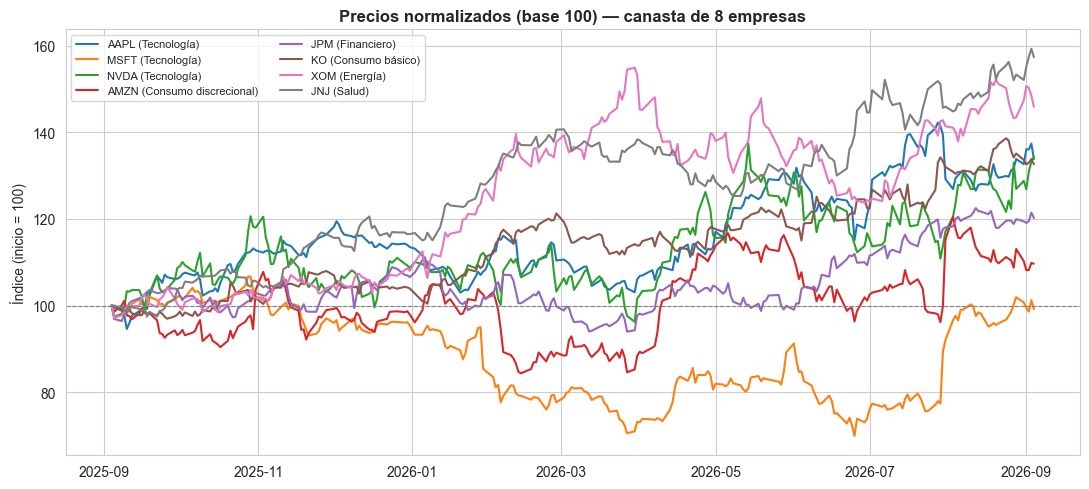

In [6]:
precios_normalizados = precios_cierre / precios_cierre.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5))
for ticker in TICKERS:
    ax.plot(precios_normalizados.index, precios_normalizados[ticker], label=f"{ticker} ({SECTOR[ticker]})")

ax.axhline(100, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Precios normalizados (base 100) — canasta de 8 empresas")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### 2.2 Estados financieros básicos

Además del precio, `yfinance` expone estados financieros (`income_stmt`, `balance_sheet`) para cada empresa a través de `yf.Ticker`. Como estas consultas son más pesadas (y a veces fallan o vienen incompletas según la empresa), envolvemos la descarga en manejo de errores: en producción **nunca** asumas que una fuente externa responderá siempre igual.

In [7]:
def obtener_fundamentales(ticker):
    """Descarga un resumen de estados financieros para un ticker. Devuelve None si falla."""
    try:
        t = yf.Ticker(ticker)
        income = t.income_stmt
        balance = t.balance_sheet

        return {
            "ticker": ticker,
            "ingresos_totales": income.loc["Total Revenue"].iloc[0] if "Total Revenue" in income.index else np.nan,
            "utilidad_neta": income.loc["Net Income"].iloc[0] if "Net Income" in income.index else np.nan,
            "deuda_total": balance.loc["Total Debt"].iloc[0] if "Total Debt" in balance.index else np.nan,
            "patrimonio": balance.loc["Stockholders Equity"].iloc[0] if "Stockholders Equity" in balance.index else np.nan,
        }
    except Exception as e:
        print(f"  ⚠ No se pudo obtener información fundamental de {ticker}: {e}")
        return None

TICKERS_FUNDAMENTALES = ["AAPL", "JPM", "KO"]  # subconjunto: estas consultas son más lentas
filas_fundamentales = [f for f in (obtener_fundamentales(tk) for tk in TICKERS_FUNDAMENTALES) if f is not None]

fundamentales = pd.DataFrame(filas_fundamentales).set_index("ticker")
fundamentales["margen_neto"] = fundamentales["utilidad_neta"] / fundamentales["ingresos_totales"]
fundamentales["deuda_patrimonio"] = fundamentales["deuda_total"] / fundamentales["patrimonio"]
fundamentales

,ingresos_totales,utilidad_neta,deuda_total,patrimonio,margen_neto,deuda_patrimonio
ticker,,,,,,
AAPL,4.161610e+11,1.120100e+11,9.865700e+10,7.373300e+10,0.269151,1.338030
JPM,1.818470e+11,5.704800e+10,4.999820e+11,3.624380e+11,0.313714,1.379497
KO,4.794100e+10,1.310700e+10,4.549200e+10,3.216900e+10,0.273399,1.414156


### 2.3 Una fuente de datos muy distinta: *credit scoring*

Para contrastar, incorporamos un dataset de **crédito al consumidor**, del estilo del clásico *Give Me Some Credit* (Kaggle): cada fila es una **persona**, no una empresa ni un día de mercado, y la variable objetivo es binaria (¿incumplió en los próximos 2 años?), no un precio continuo.

Este es exactamente el tipo de dataset real que usarás más adelante para *credit scoring*. Si tienes acceso a Kaggle, puedes descargar el dataset real (búscalo como **"Give Me Some Credit"**, o alternativamente **"Lending Club Loan Data"**) y colocarlo en `data/raw/cs-training.csv`; el siguiente bloque lo detecta automáticamente. Si no está disponible, generamos datos **sintéticos con la misma estructura de columnas y los mismos problemas de calidad típicos del dataset real** (variables faltantes, atípicos, tipos mal definidos), para que el pipeline de limpieza de la sección 3 sea idéntico al que aplicarías sobre los datos reales.

In [8]:
def generar_datos_credito_sintetico(n=4000, semilla=SEMILLA):
    """Genera un dataset con la misma estructura y los mismos problemas de calidad
    que 'Give Me Some Credit', para practicar el pipeline de limpieza sin depender
    de credenciales externas."""
    rng = np.random.default_rng(semilla)

    edad = rng.normal(45, 13, n).round().astype(int)
    utilizacion = np.abs(rng.normal(0.3, 0.35, n))          # utilización de líneas de crédito
    ratio_deuda = np.abs(rng.normal(0.35, 0.6, n))
    ingreso_mensual = rng.lognormal(mean=8.1, sigma=0.5, size=n).round(2)
    n_lineas_credito = rng.poisson(8, n)
    n_dependientes = rng.poisson(0.8, n)
    atrasos_30_59 = rng.poisson(0.3, n)
    atrasos_60_89 = rng.poisson(0.1, n)
    atrasos_90 = rng.poisson(0.1, n)
    n_inmuebles = rng.poisson(1, n)

    # Probabilidad de incumplimiento: mayor utilización, atrasos y deuda -> mayor riesgo.
    # El intercepto se calibró para que la tasa base ronde ~7%, similar a la del dataset real.
    logit = (-4.2 + 2.5 * utilizacion + 0.8 * atrasos_90 + 0.5 * atrasos_60_89
             + 0.3 * atrasos_30_59 + 0.5 * ratio_deuda - 0.01 * (edad - 45))
    prob_incumplimiento = 1 / (1 + np.exp(-logit))
    incumplimiento = rng.binomial(1, np.clip(prob_incumplimiento, 0, 1))

    df = pd.DataFrame({
        "SeriousDlqin2yrs": incumplimiento,
        "RevolvingUtilizationOfUnsecuredLines": utilizacion,
        "age": edad,
        "NumberOfTime30-59DaysPastDueNotWorse": atrasos_30_59,
        "DebtRatio": ratio_deuda,
        "MonthlyIncome": ingreso_mensual,
        "NumberOfOpenCreditLinesAndLoans": n_lineas_credito,
        "NumberOfTimes90DaysLate": atrasos_90,
        "NumberRealEstateLoansOrLines": n_inmuebles,
        "NumberOfTime60-89DaysPastDueNotWorse": atrasos_60_89,
        "NumberOfDependents": n_dependientes,
    })

    # ── Se inyectan deliberadamente los mismos problemas de calidad del dataset real ──
    idx_ingreso_nulo = rng.choice(n, size=int(n * 0.20), replace=False)      # ~20% de faltantes en MonthlyIncome, igual que en los datos reales
    df.loc[idx_ingreso_nulo, "MonthlyIncome"] = np.nan

    idx_dependientes_nulo = rng.choice(n, size=int(n * 0.03), replace=False)
    df.loc[idx_dependientes_nulo, "NumberOfDependents"] = np.nan

    idx_edad_atipica = rng.choice(n, size=5, replace=False)
    df.loc[idx_edad_atipica, "age"] = 0                                     # edad = 0, error de captura conocido en el dataset real

    idx_utilizacion_atipica = rng.choice(n, size=10, replace=False)
    df.loc[idx_utilizacion_atipica, "RevolvingUtilizationOfUnsecuredLines"] = rng.uniform(10, 50, 10)  # utilización > 1000%

    df["age"] = df["age"].astype(str)  # tipo de dato mal definido a propósito (debería ser numérico)

    return df

ruta_local_real = "data/raw/cs-training.csv"
if os.path.exists(ruta_local_real):
    datos_credito = pd.read_csv(ruta_local_real)
    print("Usando el dataset real encontrado en", ruta_local_real)
else:
    datos_credito = generar_datos_credito_sintetico()
    print("No se encontró un dataset real local: usando datos sintéticos con la misma estructura.")

datos_credito.head()

No se encontró un dataset real local: usando datos sintéticos con la misma estructura.


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.388622,49,0,0.550161,2821.73,9,0,1,0,1.0
1,0,0.613326,31,1,1.091806,3395.20,9,0,1,0,0.0
2,1,0.395662,55,1,1.079498,1771.57,12,0,1,0,3.0
3,0,1.083591,57,0,0.079426,1646.03,3,0,1,0,1.0
4,0,0.800426,20,0,0.466410,3608.87,11,0,2,0,0.0


### 2.4 Dos tipos de problema, en una sola tabla comparativa

| | Precios de mercado (sección 2.1–2.2) | Datos de crédito (sección 2.3) |
|---|---|---|
| **Unidad de observación** | Empresa – día | Persona |
| **Estructura** | Serie de tiempo | Datos transversales (*cross-sectional*) |
| **Variable objetivo típica** | Retorno futuro (continua) | Incumplimiento (binaria) |
| **Riesgo principal al modelar** | Fuga de información temporal (ver cuaderno anterior) | Sesgo de selección, variables *proxy* de discriminación |
| **Partición de datos** | Debe ser cronológica | Puede ser aleatoria (no hay orden temporal entre personas) |

Guardamos ambas fuentes descargadas, aplicando la convención de nombres de la sección 1.3.

In [9]:
ruta_precios = nombre_archivo_version("precios_acciones")
ruta_fundamentales = nombre_archivo_version("fundamentales")
ruta_credito = nombre_archivo_version("datos_credito")

precios_cierre.to_csv(ruta_precios)
fundamentales.to_csv(ruta_fundamentales)
datos_credito.to_csv(ruta_credito, index=False)

print("Archivos guardados:")
for ruta in [ruta_precios, ruta_fundamentales, ruta_credito]:
    print(" -", ruta)

Archivos guardados:
 - data/raw/precios_acciones_20260904_v2.csv
 - data/raw/fundamentales_20260904_v2.csv
 - data/raw/datos_credito_20260904_v2.csv


## 3. Pipeline de Limpieza: de `datos_credito` a una Matriz Modelable

Usamos el dataset de crédito de la sección 2.3, que ya trae —a propósito— los problemas típicos de un dataset real: valores faltantes, atípicos y una columna con el tipo de dato equivocado.

### 3.1 Diagnóstico

Antes de corregir nada, cuantificamos el problema.

In [10]:
print("Dimensiones:", datos_credito.shape)
print("\nTipos de dato:\n", datos_credito.dtypes)
print("\nValores faltantes por columna:\n", datos_credito.isna().sum())
print("\nFilas duplicadas:", datos_credito.duplicated().sum())

Dimensiones: (4000, 11)

Tipos de dato:
 SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                         str
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Valores faltantes por columna:
 SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           800
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines    

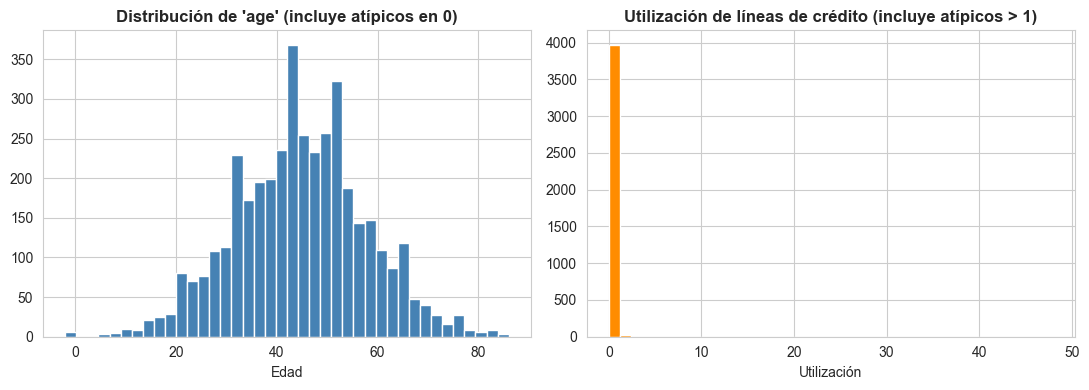

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(datos_credito["age"].astype(float), bins=40, color="steelblue")
axes[0].set_title("Distribución de 'age' (incluye atípicos en 0)")
axes[0].set_xlabel("Edad")

axes[1].hist(datos_credito["RevolvingUtilizationOfUnsecuredLines"], bins=40, color="darkorange")
axes[1].set_title("Utilización de líneas de crédito (incluye atípicos > 1)")
axes[1].set_xlabel("Utilización")

plt.tight_layout()
plt.show()

### 3.2 De correcciones sueltas a un `Pipeline`

Podríamos corregir cada problema con líneas de `pandas` sueltas, pero eso tiene un riesgo: la próxima vez que lleguen datos nuevos (o al aplicar el modelo a datos de prueba), hay que **recordar y repetir manualmente** cada corrección, en el orden correcto. `sklearn.Pipeline` resuelve esto encapsulando cada paso como un objeto que se **ajusta una vez sobre entrenamiento** (`fit`) y se **aplica consistentemente** sobre cualquier dato nuevo (`transform`) — el mismo principio de "ajustar solo con entrenamiento" que vimos para el escalado de variables en el cuaderno anterior, ahora formalizado como el patrón que usaremos en **todo el curso**.

Como los datos de crédito son transversales (no series de tiempo), aquí **sí** es válido un `train_test_split` aleatorio — a diferencia de los precios de mercado, donde vimos que la partición debe ser cronológica.

In [12]:
# Corregimos primero el tipo de dato mal definido (age llegó como texto)
datos_credito["age"] = pd.to_numeric(datos_credito["age"], errors="coerce")

objetivo = "SeriousDlqin2yrs"
X = datos_credito.drop(columns=[objetivo])
y = datos_credito[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)

print(f"Entrenamiento: {X_train.shape}  |  Prueba: {X_test.shape}")
print(f"Tasa de incumplimiento — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")

Entrenamiento: (3200, 10)  |  Prueba: (800, 10)
Tasa de incumplimiento — train: 7.81%  |  test: 7.75%


### 3.3 Un transformador propio: capado de atípicos por IQR

`sklearn` trae imputadores y escaladores listos, pero el tratamiento de atípicos suele ser específico del problema. Construimos un transformador propio compatible con `Pipeline`, heredando de `BaseEstimator` y `TransformerMixin`: aprende los límites (`fit`) **solo con entrenamiento** y los aplica (`transform`) a cualquier dato nuevo, evitando de nuevo la fuga de información.

In [13]:
class CapadorAtipicosIQR(BaseEstimator, TransformerMixin):
    """Capa (censura) valores fuera de [Q1 - factor*IQR, Q3 + factor*IQR],
    aprendiendo los límites únicamente del conjunto de entrenamiento."""

    def __init__(self, factor=3.0):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.limite_inferior_ = q1 - self.factor * iqr
        self.limite_superior_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.limite_inferior_, self.limite_superior_)

print("Transformador definido ✓")

Transformador definido ✓


In [14]:
columnas_numericas = X_train.columns.tolist()  # todas las columnas de este dataset son numéricas

pipeline_limpieza = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),   # completa faltantes con la mediana de entrenamiento
    ("capar_atipicos", CapadorAtipicosIQR(factor=3.0)),
    ("escalar", StandardScaler()),
])

X_train_limpio = pipeline_limpieza.fit_transform(X_train)   # fit + transform SOLO en entrenamiento
X_test_limpio = pipeline_limpieza.transform(X_test)          # el conjunto de prueba solo se transforma

X_train_limpio = pd.DataFrame(X_train_limpio, columns=columnas_numericas, index=X_train.index)
X_test_limpio = pd.DataFrame(X_test_limpio, columns=columnas_numericas, index=X_test.index)

print("Faltantes tras el pipeline — train:", X_train_limpio.isna().sum().sum(), "| test:", X_test_limpio.isna().sum().sum())
X_train_limpio.describe().T[["mean", "std", "min", "max"]].round(2)

Faltantes tras el pipeline — train: 0 | test: 0


,mean,std,min,max
RevolvingUtilizationOfUnsecuredLines,0.0,1.0,-1.36,4.67
age,0.0,1.0,-3.57,3.19
NumberOfTime30-59DaysPastDueNotWorse,0.0,1.0,-0.55,6.66
DebtRatio,-0.0,1.0,-1.33,4.61
MonthlyIncome,0.0,1.0,-1.84,3.27
NumberOfOpenCreditLinesAndLoans,0.0,1.0,-2.79,4.16
NumberOfTimes90DaysLate,0.0,0.0,0.00,0.00
NumberRealEstateLoansOrLines,-0.0,1.0,-1.00,4.91
NumberOfTime60-89DaysPastDueNotWorse,0.0,0.0,0.00,0.00
NumberOfDependents,0.0,1.0,-0.92,3.74


### 3.4 Persistir el pipeline ajustado

El pipeline ya ajustado es, en sí mismo, un artefacto reutilizable: lo guardamos con `joblib` para poder aplicarlo sobre datos nuevos sin volver a ajustarlo, siguiendo la misma convención de nombres de la sección 1.

In [15]:
ruta_pipeline = nombre_archivo_version("pipeline_limpieza_credito", extension="joblib", carpeta="data/processed")
joblib.dump(pipeline_limpieza, ruta_pipeline)
print("Pipeline guardado en:", ruta_pipeline)

Pipeline guardado en: data/processed/pipeline_limpieza_credito_20260904_v2.joblib


## 4. Mini-Reto de Flujo Completo (Diagnóstico en Equipos de 2)

### Contexto

Este ejercicio funciona como **diagnóstico de nivel de Python** al inicio del curso: no se espera un resultado perfecto, sino observar cómo cada equipo razona y prioriza frente a un dataset crudo bajo presión de tiempo.

### Instrucciones

- **Equipos**: parejas (asignadas o libres, según defina el docente).
- **Tiempo**: 45 minutos, sin excepciones.
- **Punto de partida**: el archivo crudo generado en la celda siguiente (`reto_datos_crudos_*.csv`), que combina precios y variables fundamentales de las empresas de la sección 2, deliberadamente desordenado.
- **Entregable**: un notebook (`Equipo{N}_reto_flujos_v1.ipynb`, siguiendo la convención de la sección 1.3) que, a partir del CSV crudo, produzca un `DataFrame` **modelable**.

### ¿Qué significa "modelable"? — checklist de entrega

- [ ] Cada columna tiene el tipo de dato correcto (fechas como `datetime`, números como `float`/`int`, no como texto).
- [ ] No quedan valores faltantes sin una decisión explícita y justificada (imputación, eliminación, o una columna indicadora de que el dato faltaba).
- [ ] No hay filas duplicadas.
- [ ] Las categorías de texto están estandarizadas (sin mayúsculas/minúsculas mezcladas, sin espacios extra, sin dos etiquetas distintas para el mismo valor).
- [ ] Existe una variable objetivo (o al menos una propuesta razonada de cuál sería) claramente identificada.
- [ ] El equipo puede explicar, en una frase por columna, qué decisión tomó y por qué.

### Rúbrica sugerida (100 puntos)

| Criterio | Peso | Qué se evalúa |
|---|---|---|
| Diagnóstico inicial | 20 | Identifican correctamente los problemas del dataset antes de corregir |
| Corrección de tipos y duplicados | 20 | `dtypes` correctos, sin duplicados |
| Tratamiento de faltantes y atípicos | 25 | Decisiones justificadas, no solo `dropna()` indiscriminado |
| Uso del patrón de la sección 1 | 15 | El notebook entregado sigue la plantilla de 5 etapas |
| Claridad y justificación | 20 | Explican el *porqué* de cada decisión, no solo el *qué* |

### Generación del dataset crudo del reto (uso del docente)

La siguiente celda produce el archivo que se entrega a los estudiantes. **No** contiene la solución: solo empaqueta datos reales ya descargados en la sección 2 con desorden típico de una exportación descuidada (columnas con símbolos de moneda, formatos de fecha inconsistentes, filas duplicadas, texto sin estandarizar).

In [16]:
def generar_dataset_reto(precios, fundamentales, sectores, semilla=SEMILLA):
    """Combina precios y fundamentales reales en un dataset crudo y desordenado
    para el mini-reto. No resuelve el ejercicio, solo lo empaqueta."""
    rng = np.random.default_rng(semilla)

    ultimo_precio = precios.iloc[-1]
    retorno_3m = precios.iloc[-1] / precios.iloc[-63] - 1

    filas = []
    for ticker in precios.columns:
        fila = {
            "Ticker ": f" {ticker}",                                      # espacios sueltos en nombre y valores
            "Sector": sectores.get(ticker, "Desconocido").upper() if rng.random() < 0.5 else sectores.get(ticker, "desconocido").lower(),
            "PrecioActual": f"${ultimo_precio[ticker]:,.2f}",             # numérico disfrazado de texto, con símbolo y coma
            "Retorno3M(%)": f"{retorno_3m[ticker] * 100:.1f}%",           # numérico disfrazado de texto, con símbolo %
            "IngresosTotales": fundamentales.loc[ticker, "ingresos_totales"] if ticker in fundamentales.index else None,
            "FechaCorte": rng.choice(["2026-09-04", "04/09/2026", "2026.09.04"]),  # formatos de fecha inconsistentes
        }
        filas.append(fila)

    df_reto = pd.DataFrame(filas)
    df_reto = pd.concat([df_reto, df_reto.iloc[[0]]], ignore_index=True)  # una fila duplicada
    return df_reto

dataset_reto = generar_dataset_reto(precios_cierre, fundamentales, SECTOR)

ruta_reto = nombre_archivo_version("reto_datos_crudos")
dataset_reto.to_csv(ruta_reto, index=False)

print("Dataset del mini-reto guardado en:", ruta_reto)
dataset_reto

Dataset del mini-reto guardado en: data/raw/reto_datos_crudos_20260904_v2.csv


,Ticker,Sector,PrecioActual,Retorno3M(%),IngresosTotales,FechaCorte
0,AAPL,tecnología,$319.70,6.1%,4.161610e+11,04/09/2026
1,AMZN,consumo discrecional,$258.39,5.4%,NaN,04/09/2026
2,JNJ,salud,$275.03,19.0%,NaN,2026-09-04
3,JPM,financiero,$358.36,15.7%,1.818470e+11,2026-09-04
4,KO,consumo básico,$88.03,11.4%,4.794100e+10,2026.09.04
5,MSFT,TECNOLOGÍA,$499.54,21.6%,NaN,2026.09.04
6,NVDA,TECNOLOGÍA,$230.18,10.3%,NaN,04/09/2026
7,XOM,energía,$159.33,5.7%,NaN,04/09/2026
8,AAPL,tecnología,$319.70,6.1%,4.161610e+11,04/09/2026


> **Nota para el docente**: se recomienda revisar en los últimos 5 minutos únicamente el `df.info()` y `df.head()` de cada equipo, sin corregir el ejercicio en el momento — es un diagnóstico, no una entrega evaluable con retroalimentación detallada inmediata. La corrección detallada, si aplica, puede hacerse después de clase contra la checklist de la sección anterior.

## 5. Conclusiones

- El patrón `Carga → Limpieza → Features → Modelo → Evaluación` (sección 1) es la estructura que reutilizarás en **cada** sesión del curso, no un ejercicio aislado.
- Trabajar con datos reales (`yfinance`) obliga a manejar fallas, límites de la fuente y estructuras distintas entre tipos de datos financieros (mercado vs. crédito) — algo que no aparece al trabajar solo con datos simulados.
- `sklearn.Pipeline` no es un detalle técnico opcional: es lo que permite aplicar exactamente el mismo proceso de limpieza a datos nuevos sin fuga de información, y es el patrón que verás una y otra vez en el curso.
- El mini-reto no busca un resultado perfecto: es una foto del punto de partida de cada equipo, útil tanto para el docente (calibrar el curso) como para cada estudiante (saber en qué reforzar).

**Próximos pasos**: en las siguientes sesiones, cada nuevo tema (series de tiempo, modelos de clasificación para *scoring*, portafolios) partirá de esta misma plantilla, reemplazando únicamente lo específico del problema.